# 06j — MSA positional-consensus barycenter on representation quality (G=28)

**Kickoff F·S3** of the E→G→F arc — the last method in the F roster. Adds **one** principled
*positional-consensus* averager to the §17 quality harness and scores it **identically**
(extend-by-reuse; no harness change):

- **`msa_consensus`** — **center-star multiple sequence alignment** (Gusfield, *Bull. Math. Biol.* 1993;
  2-approximation for a metric cost) with a **profile per-column consensus** (Durbin, Eddy, Krogh & Mitchison,
  *Biological Sequence Analysis* 1998): align every member to the rTWE medoid (the vendored
  `rtwe_alignment_path`, the same aligner as the paper's mode-DBA), merge with "once a gap, always a gap"
  (Feng–Doolittle 1987 / ClustalW, Thompson 1994), then a Laplace-pseudocount argmax per column with a
  **50% occupancy** match-state rule. Scored by the **native rTWE** distance (like `ssg`/`fgw_*`/`k_medoid`).

**This is a Family A (native-categorical) method.** It stays entirely in symbol space — **no `D_G` embedding
and no decode** (contrast the Family-B `soft_dtw_bary`/`ssg`/`fgw_*`). That is the scientific point: the
cooking task is a *recipe*, so a per-position probabilistic consensus is the natural, statistically-principled
Family-A generalisation of `majority_voting` (multiple alignment instead of lock-step) and `tw_twe_mode`
(a proper MSA with insertion columns + occupancy, instead of an iterative single reference).

**This is a GATED preview.** L=128, few inits. The genuine gate is **length** (full L≈5162 → O(n²·L²) medoid
build ≈ 1600× the per-cell cost) and **cohort**; that scale run is handed off to `pomme` (stub at the bottom,
**not run locally**). Judged on **representation fidelity**, not discrimination AUC. Report **per-axis
tradeoffs**, no cherry-picked winner — this is a representativeness comparison, not a race.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import os
os.environ.setdefault('NUMBA_THREADING_LAYER', 'workqueue')  # fork-safe rTWE under nbconvert
import json
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display
from smartflat.utils.utils_io import get_data_root
from smartflat.features.symbolic_barycenter import vocab
from smartflat.features.symbolic_barycenter import visualization as viz
from smartflat.features.symbolic_barycenter.baselines import (
    default_baseline_methods, barycenter_mode_dba, dist_rtwe,
    fgw_methods, softdtw_ssg_methods, msa_consensus_methods)
from smartflat.features.symbolic_barycenter.barycenter_quality import (
    score_barycenter_quality, quality_table)
from smartflat.engine.distances._rtwe import rtwe_pairwise_distance
pd.set_option('display.width', 200, 'display.max_columns', 30)
plt.rcParams['figure.dpi'] = 110

OUT = os.path.join(get_data_root(), 'outputs', 'symbolic_barycenter', 'g28')
EXP = os.path.join(OUT, 'experiments'); os.makedirs(EXP, exist_ok=True)

# Hyperparameters (thesis G=28), shared length gate, and the profile-consensus knobs.
L, NU, LMBDA, RS = 128, 1e-4, 0.1, 42
MSA_PSEUDO, MSA_OCC, N_INITS = 1.0, 0.5, 2   # Laplace pseudocount, 50%-occupancy rule, gated inits
print('output dir:', EXP)

output dir: /home/perochon/data-gold-final/outputs/symbolic_barycenter/g28/experiments


In [2]:
# Canonical G=28 cohort + ground cost via E's shared loaders (06c Cells 2-3).
# msa_consensus stays in symbol space, but scoring the whole registry lock-step needs a rectangular
# length -> upsample to L=128 (the low end of 06c's L_SWEEP; gates the O(n^2*L^2) medoid build).
# Full L~5162 stays deferred to pomme.
df, X, labels = vocab.load_g28_cohort(upsample_to=L)
D_G = vocab.build_g28_ground_cost(); G = D_G.shape[0]
code_dict = json.load(open(os.path.join(OUT, 'category_codes.json')))
code_to_label = {int(v): k for k, v in code_dict.items()}

# One-time pairwise rTWE (needed by the k_medoid reference); ~seconds at L=128.
D_pw = rtwe_pairwise_distance(X.astype(np.float64), nu=NU, lmbda=LMBDA,
                             precomputed_distances=np.ascontiguousarray(D_G))
print('cohort:', df.groupby('pathologie').size().to_dict(), '| G =', G, '| X', X.shape)

cohort: {'HEALTHY': 24, 'RIL': 37, 'TBI': 59} | G = 28 | X (120, 128)


## (1) Registry — the new method + §17 reference points

`msa_consensus_methods` emits the one new `{build, distance}` entry; I merge a few §17/§18 anchors
(`wasserstein` = the winning frequency histogram, `tw_twe_mode` = the paper's mode-DBA and the closest
Family-A precedent, `fgw_onehot` = F·S1's structured average, plus the F·S2 `soft_dtw_bary`/`ssg`) so the new
row is read against a fixed reference frame spanning both families.

In [3]:
base = default_baseline_methods(D_G, nu=NU, lmbda=LMBDA)
methods = {
    'wasserstein':     base['wasserstein'],       # symbol-frequency histogram (the winning baseline)
    'tw_twe_mode':     {'build': lambda Xg, s: barycenter_mode_dba(Xg, D_G, nu=NU, lmbda=LMBDA, max_iter=10),
                        'distance': lambda seq, b: dist_rtwe(seq, b, D_G, nu=NU, lmbda=LMBDA)},
}
methods.update(fgw_methods(D_G, n_nodes=L, alpha=0.5, nu=NU, lmbda=LMBDA))          # fgw_mds, fgw_onehot
methods.update(softdtw_ssg_methods(D_G, nu=NU, lmbda=LMBDA,                          # F.S2 anchors
                                   sdtw_max_iter=10, ssg_max_iter=10))
methods.update(msa_consensus_methods(D_G, nu=NU, lmbda=LMBDA,                        # <-- F.S3 addition
                                     pseudocount=MSA_PSEUDO, occupancy=MSA_OCC))
print('=== GATED PREVIEW (NOT the scale run) ===')
print(f'  L = {L} (full-length L~5162 -> O(n^2*L^2) medoid build ~1600x per-cell: DEFERRED to pomme)')
print(f'  msa_consensus: pseudocount = {MSA_PSEUDO} (Laplace), occupancy = {MSA_OCC} (50% match-state rule),'
      f' n_inits = {N_INITS}')
print('  cohort = local G=28 upsampled subset (full-cohort scale run: DEFERRED to pomme)')
print('  note: msa_consensus is Family A (native-categorical) -> no D_G embedding, no decode;')
print('        it is deterministic (medoid center + argmax consensus), so random_state is unused.')
print('scored:', list(methods))

=== GATED PREVIEW (NOT the scale run) ===
  L = 128 (full-length L~5162 -> O(n^2*L^2) medoid build ~1600x per-cell: DEFERRED to pomme)
  msa_consensus: pseudocount = 1.0 (Laplace), occupancy = 0.5 (50% match-state rule), n_inits = 2
  cohort = local G=28 upsampled subset (full-cohort scale run: DEFERRED to pomme)
  note: msa_consensus is Family A (native-categorical) -> no D_G embedding, no decode;
        it is deterministic (medoid center + argmax consensus), so random_state is unused.
scored: ['wasserstein', 'tw_twe_mode', 'fgw_mds', 'fgw_onehot', 'soft_dtw_bary', 'ssg', 'msa_consensus']


## (2) Extended methods × quality-metric table (L=128, gated budget)

In [4]:
res = score_barycenter_quality(X, labels, methods, D_G, D_pairwise=D_pw,
                               n_inits=N_INITS, random_state=RS)
q = quality_table(res)
q_show = q.drop(columns=['stability_inertia_rtwe', 'stability_histogram'])
# Discreteness family (see BARYCENTER_METHOD_DISCRETENESS.md / RESULTS_HANDOFF §18.4, §19):
#   A = native-categorical (stays in symbol space; votes/median/medoid over real symbols)
#   B = continuous-relaxation + decode (embed via D_G rows, average vectors, snap back at the end)
FAMILY = {'wasserstein': 'A (freq only)', 'tw_twe_mode': 'A', 'majority_voting': 'A',
          'edit_median': 'A', 'k_medoid': 'A', 'transition': 'A (matrix)', 'msa_consensus': 'A',
          'fgw_mds': 'B', 'fgw_onehot': 'B', 'soft_dtw_bary': 'B', 'ssg': 'B',
          'dba_dtw': 'B', 'soft_dtw': 'B'}
q_show.insert(0, 'family', [FAMILY.get(m, '?') for m in q_show.index])
q.to_csv(os.path.join(EXP, 'barycenter_quality_msa_consensus_L128.csv'))
# group-level entropy reference for the mode-collapse lens (~3.7 bits).
grp_H = np.mean([
    -(lambda p: (p[p>0]*np.log2(p[p>0])).sum())(np.bincount(X[labels==g].ravel(), minlength=G)/ (labels==g).sum()/L)
    for g in np.unique(labels)])
print(f'group-sequence entropy reference: ~{grp_H:.2f} bits')
display(q_show.round(3))

/home/perochon/anaconda3/envs/smartflat_repro/lib/python3.11/site-packages/tslearn/bases/bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


/home/perochon/anaconda3/envs/smartflat_repro/lib/python3.11/site-packages/tslearn/barycenters/dba.py:735: ConvergenceWarning: DBA loss is increasing while it should not be. Stopping optimization.
  warnings.warn("DBA loss is increasing while it should not be. "


/home/perochon/anaconda3/envs/smartflat_repro/lib/python3.11/site-packages/tslearn/barycenters/dba.py:735: ConvergenceWarning: DBA loss is increasing while it should not be. Stopping optimization.
  warnings.warn("DBA loss is increasing while it should not be. "


/home/perochon/anaconda3/envs/smartflat_repro/lib/python3.11/site-packages/tslearn/barycenters/dba.py:735: ConvergenceWarning: DBA loss is increasing while it should not be. Stopping optimization.
  warnings.warn("DBA loss is increasing while it should not be. "


group-sequence entropy reference: ~3.78 bits


metric,family,inertia_rtwe,inertia_native,freq_fidelity,struct_preservation,entropy_bits,n_distinct,n_segments
method,,,,,,,,
fgw_mds,B,74.685,74.685,0.046,3.233,3.482,16.833,114.167
fgw_onehot,B,77.393,77.393,0.033,3.494,3.554,18.667,117.000
msa_consensus,A,42.941,42.941,0.107,2.460,3.131,12.667,51.333
soft_dtw_bary,B,47.080,-58.102,0.170,2.748,3.092,12.000,23.667
ssg,B,45.825,45.825,0.125,2.952,3.314,15.667,65.000
tw_twe_mode,A,43.817,43.817,0.103,2.642,3.017,13.000,57.333
wasserstein,A (freq only),NaN,0.122,0.027,NaN,3.724,28.000,NaN


**Reading the table (per-axis tradeoffs, no single winner).**
- **`msa_consensus`** is a Family-A alignment averager: like §17's alignment methods (and its precedent
  `tw_twe_mode`) it is competitive on the **rTWE inertia** yardstick, while — as a categorical voter — it
  keeps genuine symbols per position rather than a between-symbols mean. Read it *against* `tw_twe_mode`: the
  MSA adds insertion columns + a 50%-occupancy match-state rule, so it can differ in `n_segments` / length
  and in `entropy_bits` (the mode-collapse lens; compare to the **~3.78-bit** group reference printed above).
- The honest frame is unchanged from §17/§18: *which method is "best" depends on the chosen fidelity axis.*
  `freq_fidelity` (Wasserstein-on-`D_G`, lower = better) favours the histogram `wasserstein`; the anti-collapse
  `fgw_*` keep entropy up; the alignment/vote methods win rTWE-compactness. `msa_consensus` is offered as the
  **statistically-principled Family-A positional consensus**, not a new leaderboard winner.

**Discreteness `family` column — a fairness note (full reference: `BARYCENTER_METHOD_DISCRETENESS.md`,
RESULTS_HANDOFF §18.4 / §19).** The benchmarked averagers split into two families by *how they treat the
discrete symbol space*: **A — native-categorical** (`msa_consensus`, `tw_twe_mode`, `majority_voting`,
`edit_median`, `k_medoid`, `wasserstein`, `transition`) stays in symbol space throughout, each output position
a genuine symbol; **B — continuous relaxation + decode** (`soft_dtw_bary`, `ssg`, `dba_dtw`, `soft_dtw`,
`fgw_*`) embeds via `D_G` rows, averages real vectors, and snaps back only at the end. The benchmark stays
fair (common rTWE yardstick + each method's native distance); collapse is not unique to B.

## (3) Init-stability of the new method

`msa_consensus` is **deterministic** (medoid center + per-column argmax; `random_state` unused), so its
rTWE-inertia std over inits is ≈ 0 by construction — the honest stability signal is that there is no init
variance to report.

In [5]:
stab = score_barycenter_quality(
    X, labels,
    msa_consensus_methods(D_G, nu=NU, lmbda=LMBDA, pseudocount=MSA_PSEUDO, occupancy=MSA_OCC),
    D_G, D_pairwise=D_pw, n_inits=3, random_state=RS)
display(quality_table(stab)[['inertia_rtwe', 'stability_inertia_rtwe', 'entropy_bits']].round(4))

metric,inertia_rtwe,stability_inertia_rtwe,entropy_bits
method,,,
msa_consensus,42.9409,0.0,3.1309


## (4) Per-method barycenter chronograms (degeneracy eyeballing)

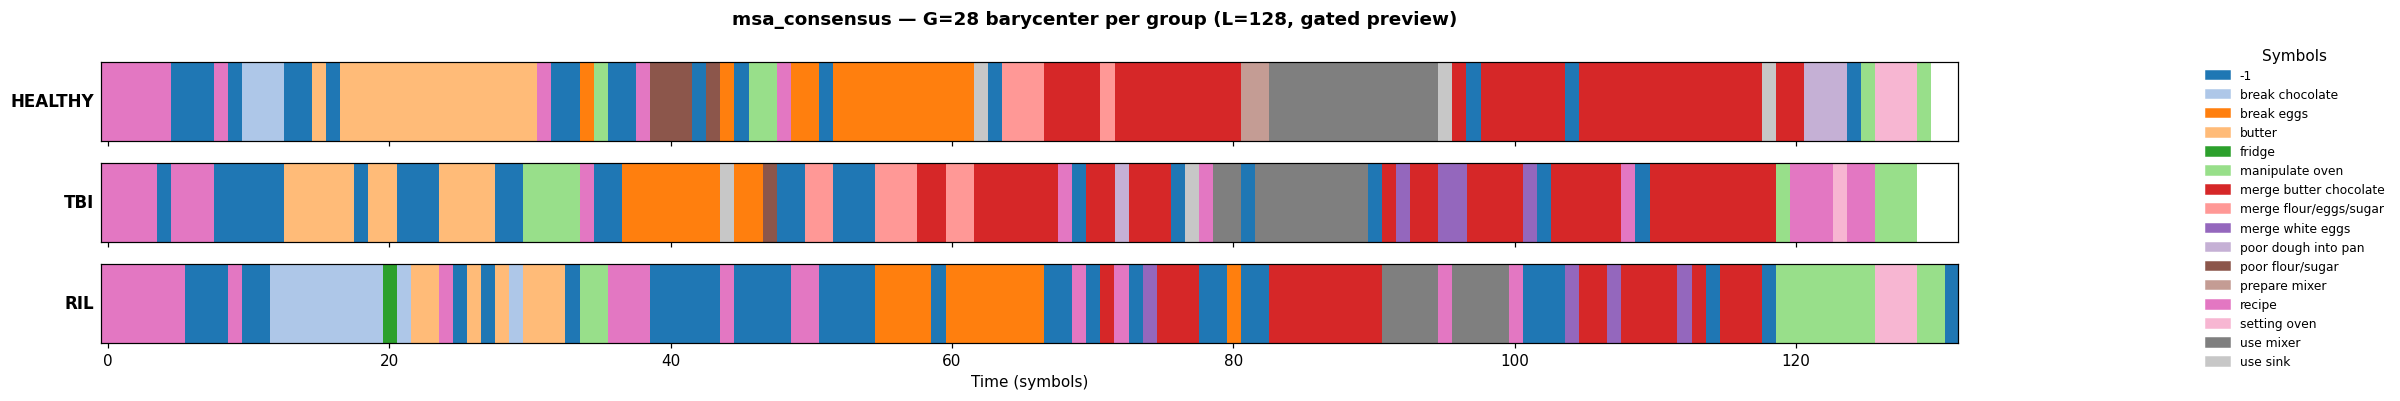

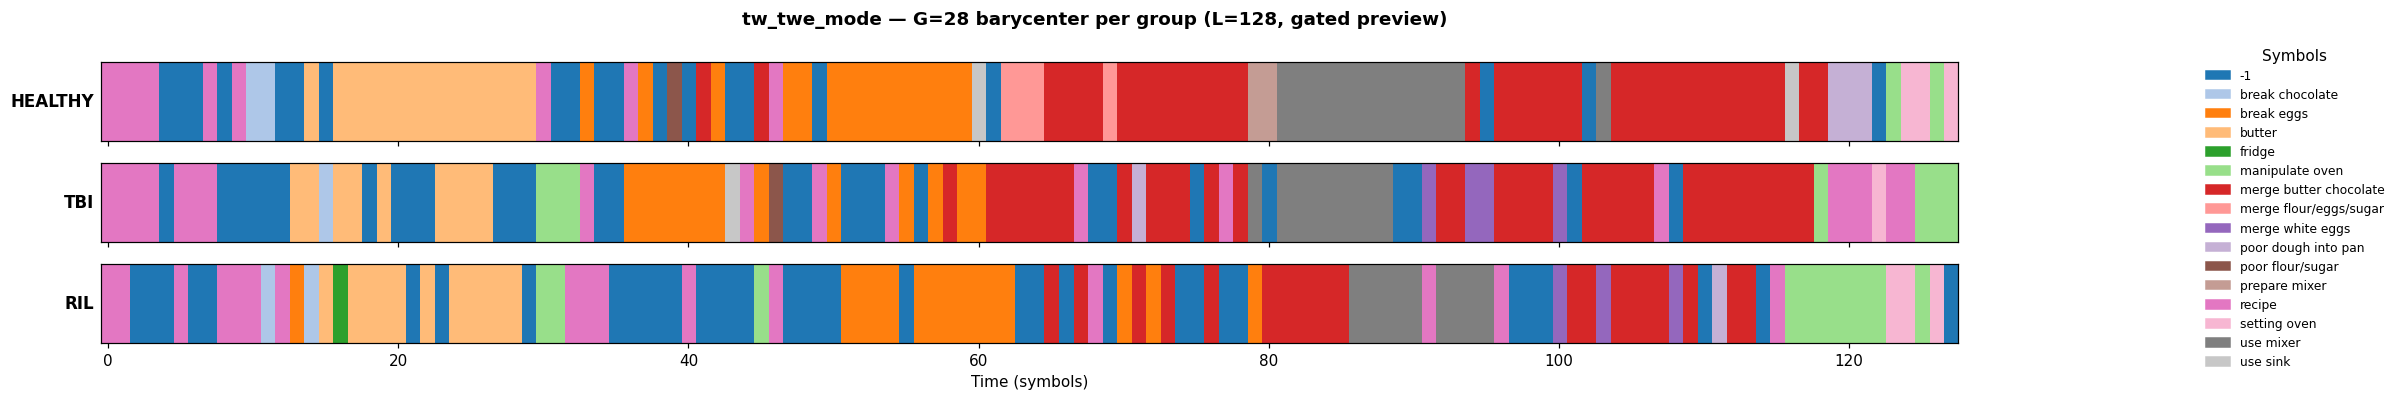

/home/perochon/anaconda3/envs/smartflat_repro/lib/python3.11/site-packages/tslearn/barycenters/dba.py:735: ConvergenceWarning: DBA loss is increasing while it should not be. Stopping optimization.
  warnings.warn("DBA loss is increasing while it should not be. "


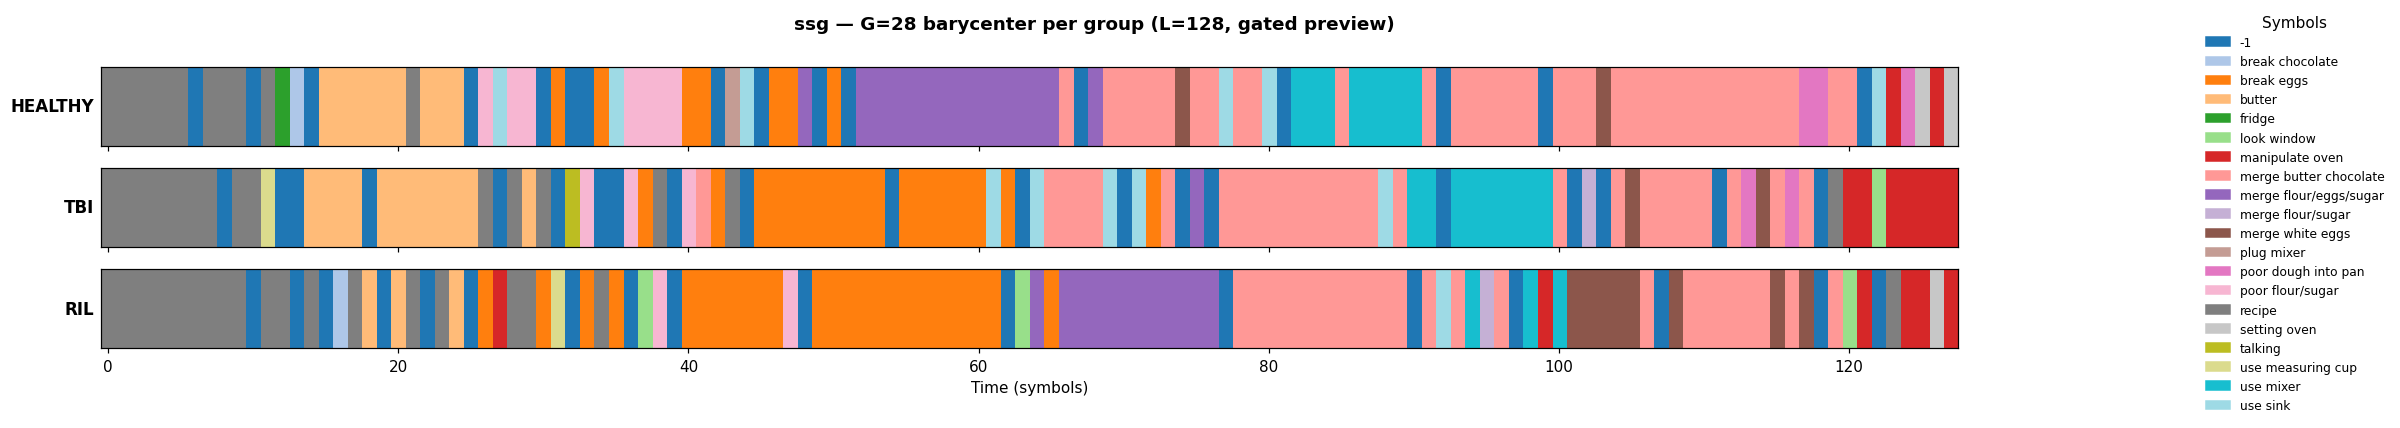

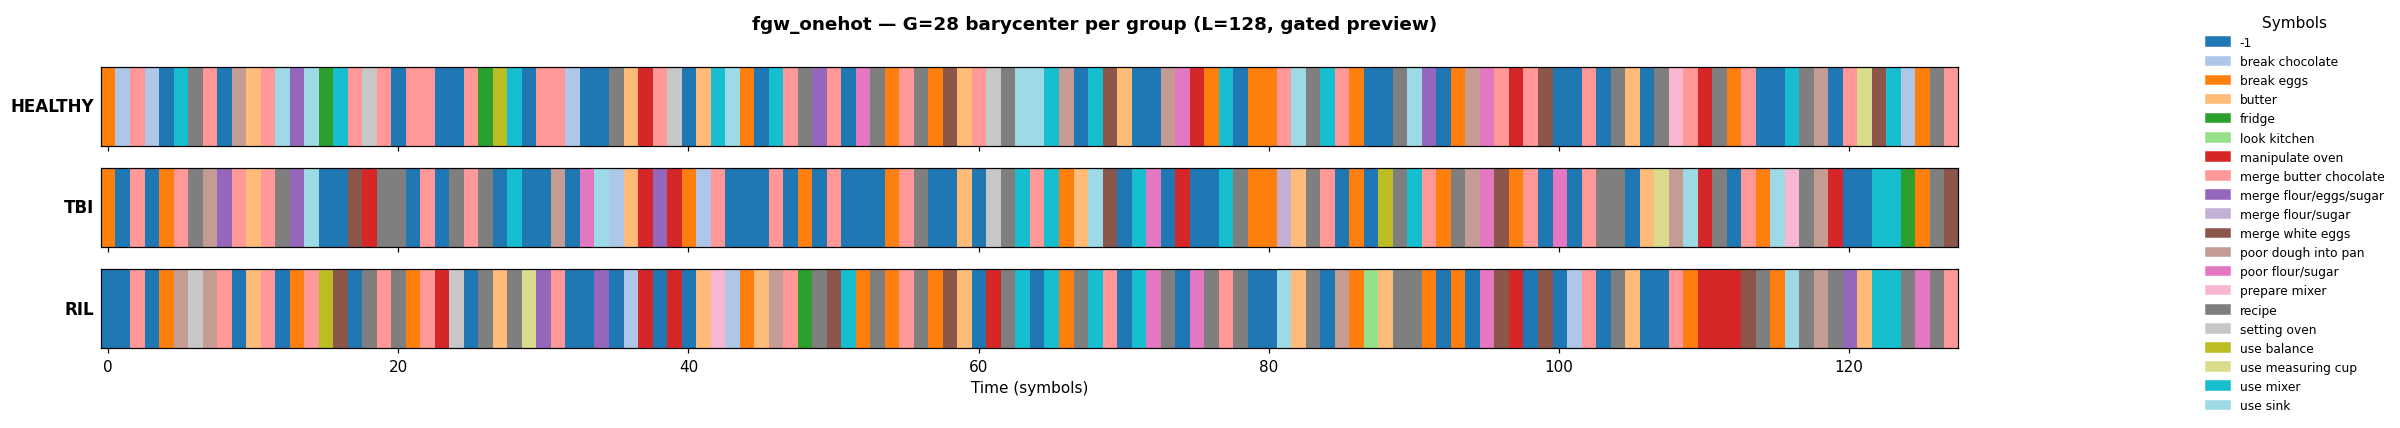

In [6]:
CHRONO_METHODS = ['msa_consensus', 'tw_twe_mode', 'ssg', 'fgw_onehot']
groups = ['HEALTHY', 'TBI', 'RIL']
def _as_seq(name, spec, Xg):
    if spec.get('kind') == 'medoid':
        idx = int(np.argmin(rtwe_pairwise_distance(
            Xg.astype(np.float64), nu=NU, lmbda=LMBDA,
            precomputed_distances=np.ascontiguousarray(D_G)).sum(1)))
        return np.asarray(Xg[idx]).astype(int)
    b = np.asarray(spec['build'](Xg, RS))
    if b.ndim == 2:            # transition matrix -> skip (no sequence)
        return None
    if b.ndim == 1 and b.shape[0] == G and np.issubdtype(b.dtype, np.floating):
        return np.full(L, int(np.argmax(b)), dtype=int)   # histogram -> argmax reference strip
    return b.astype(int)       # symbol sequence (msa_consensus length may differ slightly per group)

for name in CHRONO_METHODS:
    spec = methods[name]
    barys = {g: _as_seq(name, spec, X[labels == g].astype(int)) for g in groups}
    barys = {g: v for g, v in barys.items() if v is not None}
    fig = viz.plot_cohort_barycenters(barys, groups=list(barys), code_to_label=code_to_label,
                                      title=f'{name} — G=28 barycenter per group (L={L}, gated preview)')
    fig.savefig(os.path.join(EXP, f'chronogram_msa_{name}.png'), dpi=150, bbox_inches='tight')
    display(fig); plt.close(fig)

## (5) Scale hand-off — stub retained; the full-length run was attempted and abandoned

The cell below is a **stub — NOT run locally**. It documents the full-length (L≈5162) / full-cohort
invocation.

**Status (§25): that run was attempted on `pomme` and abandoned as impractical.** Two detached runs
each ran >25 h wall (~2.25 of 96 cores) and never completed even the first method family; no
`*_FULL.csv` was produced. The cause is fundamental rather than a hardware gap: the O(n²·L²) medoid
build is **single-threaded per build**, and §25 modelled the parallel case explicitly — even ideal
`(group×method×init)` parallelism leaves `msa_consensus` (only **3 group-units**) at ~a day.
**The L=128 preview above therefore stands as the canonical §19 result** (§26 keeps the roster at
L=128). The stub is retained per §25 for anyone with a parallelised harness or a much shorter L —
**a tractable middle ground is L≈512** (~100× cheaper).

In [7]:
# --- run at scale on pomme (NOT run locally) ---
# Full-length (no upsample -> ragged native L up to ~5162) + full G=28 cohort.
# msa_consensus is Family A (no embedding); dominant cost is the O(n^2*L^2) pairwise-rTWE medoid
# selection -> ~1600x the per-cell cost of this L=128 preview -> pomme only.
#
# from smartflat.features.symbolic_barycenter import vocab
# from smartflat.features.symbolic_barycenter.baselines import msa_consensus_methods
# from smartflat.features.symbolic_barycenter.barycenter_quality import (
#     score_barycenter_quality, quality_table)
#
# L_FULL = 5162                       # or per-group native max length
# df, X, labels = vocab.load_g28_cohort(upsample_to=L_FULL)   # rectangular for lock-step scoring
# D_G = vocab.build_g28_ground_cost()
# methods = msa_consensus_methods(D_G, nu=1e-4, lmbda=0.1, pseudocount=1.0, occupancy=0.5)
# res = score_barycenter_quality(X, labels, methods, D_G, n_inits=1, random_state=42)  # deterministic
# quality_table(res).to_csv('barycenter_quality_msa_consensus_FULL.csv')
print('pomme scale-run stub — not executed locally')

pomme scale-run stub — not executed locally


## Summary (→ `RESULTS_HANDOFF_barycenters.md` §19)

One principled Family-A positional-consensus averager (`msa_consensus` — center-star rTWE MSA + profile
per-column consensus) now scores through the same §17 harness. It is the native-categorical counterpart to
F·S1's FGW and F·S2's Soft-DTW/SSG (all Family B): it stays in symbol space, with no `D_G` embedding and no
decode. Consistent with the §17/§18 verdict, it is an **honest per-axis tradeoff**, not a new winner — a
statistically-grounded alternative to the ad-hoc lock-step `majority_voting` and the iterative single-reference
`tw_twe_mode`. Numbers above are a **gated L=128 preview**; the full-length / full-cohort run is deferred to
`pomme`.